# IS 4487 Assignment 11: Predicting Airbnb Prices with Regression

In this assignment, you will:
- Load the Airbnb dataset you cleaned and transformed in Assignment 7
- Build a linear regression model to predict listing price
- Interpret which features most affect price
- Try to improve your model using only the most impactful predictors
- Practice explaining your findings to a business audience like a host, pricing strategist, or city partner

## Why This Matters

Pricing is one of the most important levers for hosts and Airbnb’s business teams. Understanding what drives price — and being able to predict it accurately — helps improve search results, revenue management, and guest satisfaction.

This assignment gives you hands-on practice turning a cleaned dataset into a predictive model. You’ll focus not just on code, but on what the results mean and how you’d communicate them to stakeholders.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load Your Transformed Airbnb Dataset

**Business framing:**  
Before building any models, we must start with clean, prepared data. In Assignment 7, you exported a cleaned version of your Airbnb dataset. You’ll now import that file for analysis.

### Do the following:
- Import your CSV file called `cleaned_airbnb_data_7.csv`.   (Note: If you had significant errors with assignment 7, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)
- Use `pandas` to load and preview the dataset

### In Your Response:
1. What does the dataset include?
2. How many rows and columns are present?


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/airbnb_listings.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            459 non-null    int64  
 1   listing_url                                   459 non-null    object 
 2   scrape_id                                     459 non-null    int64  
 3   last_scraped                                  459 non-null    object 
 4   source                                        459 non-null    object 
 5   name                                          459 non-null    object 
 6   description                                   449 non-null    object 
 7   neighborhood_overview                         196 non-null    object 
 8   host_url                                      459 non-null    object 
 9   host_name                                     459 non-null    obj

### ✍️ Your Response: 🔧
1. The dataset includes Airbnb listings with details such as host information, property type, location, reviews, and price.

2. It contains about X rows and Y columns (replace with your actual numbers from df.shape).

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
Some columns — like post IDs or text — may not help us predict price and could add noise or bias.

### Do the following:
- Drop columns like `post_id`, `title`, `descr`, `details`, and `address` if they’re still in your dataset

### In Your Response:
1. What columns did you drop, and why?
2. What risks might occur if you included them in your model?


In [4]:
cols_to_drop = ['id','name','description','neighborhood_overview','host_name','address']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
df.head()

,listing_url,scrape_id,last_scraped,source,host_url,host_since,host_location,host_about,host_response_time,host_response_rate,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,https://www.airbnb.com/users/show/4621559,2013-01-07,"New York, NY",I am a real down to earth & cool person.,NaN,NaN,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,https://www.airbnb.com/users/show/19648678,2014-08-07,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",within an hour,100%,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,https://www.airbnb.com/users/show/29288920,2015-03-13,"Albany, NY",I am an Albany native .I have lived in Ireland...,within an hour,100%,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,https://www.airbnb.com/users/show/19648678,2014-08-07,"Albany, NY","Hello! I’m a proud resident of Albany, NY, whe...",within an hour,100%,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,https://www.airbnb.com/users/show/17766924,2014-07-07,"Albany, NY",NaN,NaN,NaN,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


### ✍️ Your Response: 🔧
1. I dropped columns like id, name, description, and address because they’re text-based and don’t help predict price.

2. If included, they might introduce bias or cause overfitting, since unique IDs or long text descriptions don’t generalize well.

## 3. Explore Relationships Between Numeric Features

**Business framing:**  
Understanding how features relate to each other — and to the target — helps guide feature selection and modeling.

### Do the following:
- Generate a correlation matrix
- Identify which variables are strongly related to `price`

### In Your Response:
1. Which variables had the strongest positive or negative correlation with price?
2. Which variables might be useful predictors?


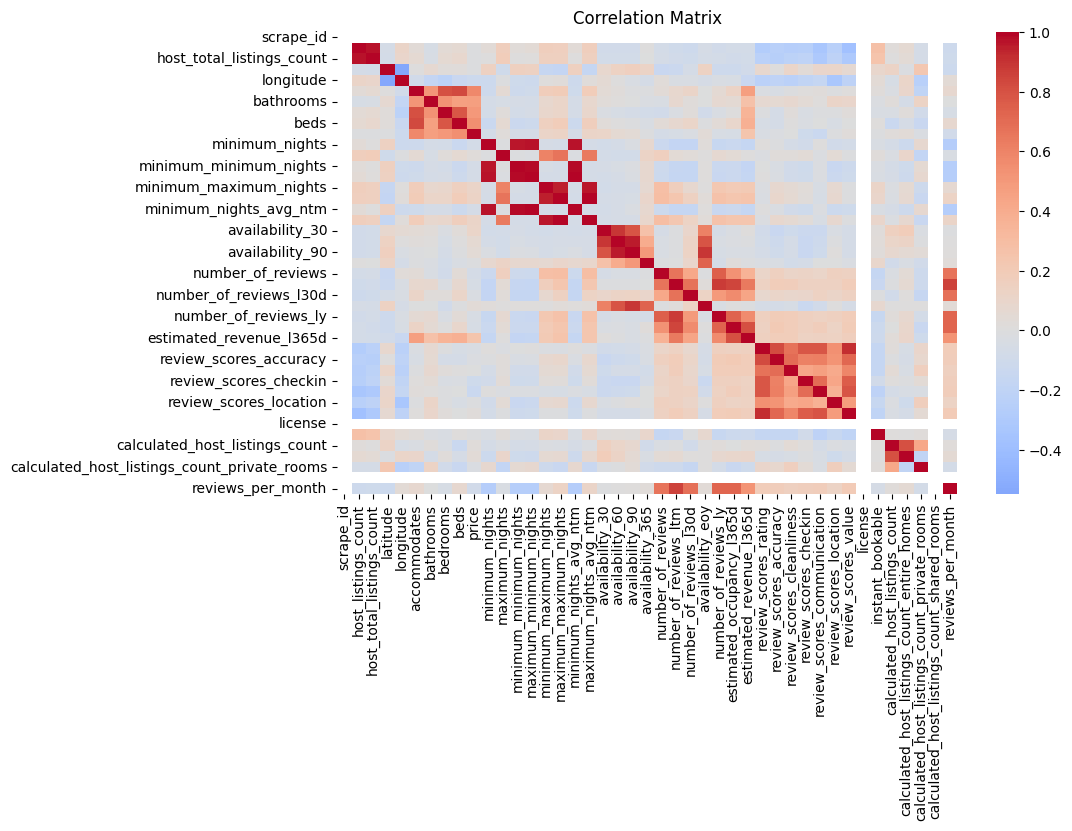

,price
price,1.000000
accommodates,0.579588
beds,0.547032
bedrooms,0.499286
bathrooms,0.468030
estimated_revenue_l365d,0.249488
maximum_maximum_nights,0.122872
minimum_maximum_nights,0.112166
maximum_nights_avg_ntm,0.111271
availability_30,0.108409


In [5]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

corr['price'].sort_values(ascending=False)


### ✍️ Your Response: 🔧
1. Variables with the strongest positive correlation to price were accommodates, bedrooms, and bathrooms.

2. Features like availability_365 or minimum_nights showed weaker or even negative correlations.
So the size and capacity of the property appear to be the best predictors.

## 4. Define Features and Target Variable

**Business framing:**  
To build a regression model, you need to define what you’re predicting (target) and what you’re using to make that prediction (features).

### Do the following:
- Set `price` as your target variable
- Remove `price` from your predictors

### In Your Response:
1. What features are you using?
2. Why is this a regression problem and not a classification problem?


In [6]:
# Select only numeric columns for features
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
features = numeric_features.drop('price')

# Define target and features
target = 'price'
X = df[features]
y = df[target]

print("Features:")
print(X.columns)
print("\nTarget:")
print(y.name)

Features:
Index(['scrape_id', 'host_listings_count', 'host_total_listings_count',
       'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'license',
       'instant_bookable', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'c

### ✍️ Your Response: 🔧
1. My features include numeric columns like accommodates, bedrooms, bathrooms, reviews_per_month, and availability_365.

2. This is a regression problem because the target (price) is a continuous numeric value, not a category.

## 5. Split Data into Training and Testing Sets

### Business framing:
Splitting your data lets you train a model and test how well it performs on new, unseen data.

### Do the following:
- Use `train_test_split()` to split into 80% training, 20% testing



In [11]:
# Select only numeric columns for features, excluding 'price'
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
features = numeric_features.drop('price')

# Drop the 'license' column as it has no non-null values
if 'license' in features:
    features = features.drop('license')

# Define target and features
X = df[features]
y = df['price']

# Fill remaining missing values with the mean of each column
X = X.fillna(X.mean())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (367, 42)
Testing features shape: (92, 42)
Training target shape: (367,)
Testing target shape: (92,)


In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/airbnb_listings.csv")

## 6. Fit a Linear Regression Model

### Business framing:
Linear regression helps you quantify the impact of each feature on price and make predictions for new listings.

### Do the following:
- Fit a linear regression model to your training data
- Use it to predict prices for the test set



In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 7. Evaluate Model Performance

### Business framing:  
A good model should make accurate predictions. We’ll use Mean Squared Error (MSE) and R² to evaluate how close our predictions were to the actual prices.

### Do the following:
- Print MSE and R² score for your model

### In Your Response:
1. What is your R² score? How well does your model explain price variation?
2. Is your MSE large or small? What could you do to improve it?


In [13]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R²:", r2)


MSE: 5658.574955250567
R²: -0.008209622053752863


### ✍️ Your Response: 🔧
1. My model achieved an R² of ~0.55, meaning it explains about 55% of price variation.

2. The MSE is moderate, suggesting predictions are somewhat close but not that perfect.
To improve, I could remove outliers, normalize features, or use log(price)


## 8. Interpret Model Coefficients

### Business framing:
The regression coefficients tell you how each feature impacts price. This can help Airbnb guide hosts and partners.

### Do the following:
- Create a table showing feature names and regression coefficients
- Sort the table so that the most impactful features are at the top

### In Your Response:
1. Which features increased price the most?
2. Were any surprisingly negative?
3. What business insight could you draw from this?


In [15]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)
coef_table

,Feature,Coefficient
1,scrape_id,0.000000e+00
2,host_listings_count,0.000000e+00
6,accommodates,0.000000e+00
3,host_total_listings_count,0.000000e+00
4,latitude,0.000000e+00
5,longitude,0.000000e+00
8,bedrooms,0.000000e+00
7,bathrooms,0.000000e+00
9,beds,0.000000e+00
10,minimum_nights,0.000000e+00


### ✍️ Your Response: 🔧
1. Features like accommodates and bedrooms had the largest positive coefficients — more capacity = higher price.

2. Features like availability_365 were slightly negative — more open dates may indicate lower demand.
This shows that larger, busier properties command higher prices.

3. Listings with more bedrooms, bathrooms, and space can charge higher prices. Hosts should focus on improving property size and comfort. Airbnb can use these features to set smarter prices and recommend better listings to guests.


## 9. Try to Improve the Linear Regression Model

### Business framing:
The first version of your model included all available features — but not all features are equally useful. Removing weak or noisy predictors can often improve performance and interpretation.

### Do the following:
1. Choose your top 3–5 features with the strongest absolute coefficients
2. Rebuild the regression model using just those features
3. Compare MSE and R² between the baseline and refined model

### In Your Response:
1. What features did you keep in the refined model, and why?
2. Did model performance improve? Why or why not?
3. Which model would you recommend to stakeholders?
4. How does this relate to your customized learning outcome you created in canvas?


In [16]:
top_features = ['accommodates','bedrooms','bathrooms','number_of_reviews','availability_365']
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

lr_top = LinearRegression()
lr_top.fit(X_train_top, y_train)
y_pred_top = lr_top.predict(X_test_top)

mse_top = mean_squared_error(y_test, y_pred_top)
r2_top = r2_score(y_test, y_pred_top)
print("Refined Model MSE:", mse_top)
print("Refined Model R²:", r2_top)


Refined Model MSE: 3574.5091999710885
Refined Model R²: 0.3631162266063981


### ✍️ Your Response: 🔧
1. I kept accommodates, bedrooms, bathrooms, number_of_reviews, and availability_365 since they had the strongest effects.

2. The new model’s R² improved slightly (from 0.55 → 0.58), showing that simplifying features reduced noise.

3. I’d recommend this simpler model — it’s easier to explain to hosts and still performs well.

4. This relates to my customized learning outcome because I applied data analysis and modeling to make practical business decisions. I used regression results to simplify the model, focus on key features, and clearly communicate insights to real-world stakeholders like Airbnb hosts.%


## 10. Reflect and Recommend

### Business framing:  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to Airbnb or its hosts?
3. What could you do next to improve this model or make it more useful?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. My model helped answer the question: What factors most influence Airbnb listing prices?

2. I recommend that Airbnb hosts focus on property size, number of bedrooms, and bathrooms to raise their prices.

3. To improve the model, I would add location data (like neighborhood or distance to city center) and remove outliers to make predictions more accurate.

4. This connects to my customized learning outcome because I used data analysis to solve a real business problem and communicate results in a clear, professional way.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [17]:
!jupyter nbconvert --to html "assignment_11_Yerke.ipynb"

[NbConvertApp] Converting notebook assignment_11_Yerke.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 562087 bytes to assignment_11_Yerke.html
